## Titanic Survival Prediction — Portfolio Project
**Author**: Timothy Dzokoto

**Dataset**: Kaggle Titanic Dataset – Passenger survival records

**Objective**: Develop machine learning models to predict passenger survival on the Titanic by analyzing socio‑economic status and demographic attributes. The project explores multiple classification approaches to evaluate predictive performance and highlight key factors influencing survival outcomes.
______


## Introduction
### Problem Statement

Passenger survival during the Titanic disaster was influenced by a complex interplay of socio‑economic and demographic factors. Accurately predicting survival outcomes from attributes such as age, gender, class, and family relations provides a benchmark problem for evaluating classification models. This project leverages the Kaggle Titanic dataset to build predictive models that identify the most significant determinants of survival, offering insights into both historical patterns and modern machine learning approaches.

### Goal
The goal is to build and compare classification models that can accurately predict passenger survival on the Titanic versel.

**Features used:**
- age
- gender
- class
- family size / relationship
- Title

**Modeling approach**



In [1]:
import pandas as pd
import numpy as np


### Load the Titanic Dataset

In [2]:
# Read the titanic dataset 
titanic_df = pd.read_csv('./titanic.csv')
titanic_df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


## Step 1: Data Exploration and Understanding Missing Values

**Concept**: Before engineering features, we need to understand the dataset's structure, distributions, and missing data patterns. This helps identify which features need imputation, transformation, or removal.

**Why necessary**: 
- Missing values can bias models if not handled properly.
- Understanding distributions helps decide on imputation strategies (e.g., mean vs. median for skewed data).
- Identifies potential outliers or data quality issues.

**What I've learnt**:
- Some features like age, embark, and cabin of the dataset have missing records which needs imputation using approrpiate strategies. This ensures models efficiency.

In [3]:
# Check for missing values
print("Missing values per column:")
print(titanic_df.isnull().sum())

# Summary statistics for numerical features
print("\nNumerical features summary:")
print(titanic_df.describe())

# Check unique values in categorical features
print("\nCategorical features unique values:")
categorical_cols = ['Sex', 'Embarked', 'Pclass']
for col in categorical_cols:
    print(f"{col}: {titanic_df[col].unique()}")

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Numerical features summary:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean    

## Step 2: Handling Missing Values

**Concept**: Missing data can occur due to various reasons (data not collected, errors, etc.). We need to fill or remove these gaps to prevent model errors.

**Why necessary**:
- Most ML algorithms can't handle NaN values.
- Improper handling can introduce bias or reduce model performance.
- Different strategies: drop rows/columns, mean/median/mode imputation, or advanced methods like KNN imputation.

**Strategies for Titanic**:
- Age: Impute with median (robust to outliers)
- Embarked: Impute with mode (most common port)
- Cabin: Too many missing (687) records, so we'll extract deck info and drop the column

**What I've learnt**:
- Copy of the dataset needs to be made for this data manipulation to keep the original intact to use when needed.

In [4]:
# Make a copy of the dataframe for feature engineering
titanic_fe = titanic_df.copy()

# Impute Age with median
titanic_fe['Age'] = titanic_fe['Age'].fillna(titanic_fe['Age'].median())

# Impute Embarked with mode
titanic_fe['Embarked'] = titanic_fe['Embarked'].fillna(titanic_fe['Embarked'].mode()[0])

# For Cabin, we'll extract deck later, so no imputation needed yet
# Drop Cabin column after extracting features

print("Missing values after imputation:")
print(titanic_fe.isnull().sum())

Missing values after imputation:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


## Step 3: Feature Extraction from Text Columns

**Concept**: Text features often contain valuable information that can be extracted into categorical or numerical features using pattern matching, parsing, or NLP techniques.

**Why necessary**:
- Raw text can't be directly used by most ML algorithms.
- Hidden patterns in text (titles, prefixes) can be strong predictors.
- Reduces dimensionality while preserving important information.

**For Titanic**:
- Name: Extract titles (Mr, Mrs, Miss, etc.) - social status indicator
- Cabin: Extract deck level (A, B, C, etc.) - location on ship affected survival
- Ticket: Extract prefixes (PC, CA, etc.) - may indicate ticket type or class

**What I've learnt**:
- Some features may not contain information I intend to extract and therefore must to defaulted to a chosen value.

In [5]:
# Extract Title from Name
titanic_fe['Title'] = titanic_fe['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Simplify titles
title_mapping = {
    'Mr': 'Mr', 'Mrs': 'Mrs', 'Miss': 'Miss', 'Master': 'Master',
    'Dr': 'Officer', 'Rev': 'Officer', 'Col': 'Officer', 'Major': 'Officer',
    'Mlle': 'Miss', 'Countess': 'Royalty', 'Ms': 'Mrs', 'Lady': 'Royalty',
    'Jonkheer': 'Royalty', 'Don': 'Royalty', 'Dona': 'Royalty', 'Mme': 'Mrs',
    'Capt': 'Officer', 'Sir': 'Royalty'
}
titanic_fe['Title'] = titanic_fe['Title'].map(title_mapping).fillna('Other')

# Extract Deck from Cabin
titanic_fe['Deck'] = titanic_fe['Cabin'].str[0].fillna('Unknown')

# Extract Ticket prefix
titanic_fe['Ticket_Prefix'] = titanic_fe['Ticket'].str.extract('([A-Za-z]+)', expand=False).fillna('NoPrefix')

print("New features created:")
print("Title unique values:", titanic_fe['Title'].unique())
print("Deck unique values:", titanic_fe['Deck'].unique())
print("Ticket_Prefix unique values:", titanic_fe['Ticket_Prefix'].unique())

New features created:
Title unique values: ['Mr' 'Mrs' 'Miss' 'Master' 'Royalty' 'Officer']
Deck unique values: ['Unknown' 'C' 'E' 'G' 'D' 'A' 'B' 'F' 'T']
Ticket_Prefix unique values: ['A' 'PC' 'STON' 'NoPrefix' 'PP' 'C' 'SC' 'S' 'CA' 'SO' 'W' 'SOTON' 'Fa'
 'LINE' 'F' 'SW' 'SCO' 'P' 'WE']


## Step 4: Creating New Features from Existing Ones

**Concept**: Combining or transforming existing features to create more informative ones. This is called feature synthesis or interaction features.

**Why necessary**:
- Captures relationships between features that individual features miss.
- Can improve model performance by providing higher-level abstractions.
- Domain knowledge helps create meaningful combinations.

**For Titanic**:
- FamilySize: Total family members (SibSp + Parch + 1)
- IsAlone: Binary feature for solo travelers
- AgeGroup: Binned age categories
- FareGroup: Binned fare categories

**What I have learnt**:
- By creating new features helps models capture meaningful patterns and improves both accuracy and interpretability which raw data missed.

In [6]:
# Create FamilySize
titanic_fe['FamilySize'] = titanic_fe['SibSp'] + titanic_fe['Parch'] + 1

# Create IsAlone
titanic_fe['IsAlone'] = (titanic_fe['FamilySize'] == 1).astype(int)

# Create AgeGroup
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior']
titanic_fe['AgeGroup'] = pd.cut(titanic_fe['Age'], bins=bins, labels=labels, right=False)

# Create FareGroup
fare_bins = [0, 7.91, 14.45, 31, 1000]
fare_labels = ['Low', 'Medium', 'High', 'VeryHigh']
titanic_fe['FareGroup'] = pd.cut(titanic_fe['Fare'], bins=fare_bins, labels=fare_labels, right=False)

print("New features created:")
print("FamilySize range:", titanic_fe['FamilySize'].min(), "-", titanic_fe['FamilySize'].max())
print("IsAlone distribution:", titanic_fe['IsAlone'].value_counts())
print("AgeGroup distribution:", titanic_fe['AgeGroup'].value_counts())
print("FareGroup distribution:", titanic_fe['FareGroup'].value_counts())


New features created:
FamilySize range: 1 - 11
IsAlone distribution: IsAlone
1    537
0    354
Name: count, dtype: int64
AgeGroup distribution: AgeGroup
YoungAdult    543
Adult         209
Child          68
Teen           45
Senior         26
Name: count, dtype: int64
FareGroup distribution: FareGroup
High        226
VeryHigh    225
Low         223
Medium      217
Name: count, dtype: int64


## Step 5: Encoding Categorical Variables

**Concept**: Converting categorical (text) features into numerical representations that ML algorithms can understand.

**Why necessary**:
- ML algorithms require numerical inputs.
- Different encoding methods preserve different types of information (ordinal vs nominal).

**Methods**:
- One-Hot Encoding: For nominal categories (no order) - creates binary columns
- Label Encoding: For ordinal categories (has order) - assigns integers
- Target Encoding: Uses target variable statistics (advanced, can cause leakage)

**For Titanic**:
- Sex, Embarked, Title, Deck, Ticket_Prefix, AgeGroup, FareGroup: One-hot encode
- Pclass: Already ordinal (1,2,3), keep as is

In [7]:
# One-hot encode categorical variables
categorical_cols = ['Sex', 'Embarked', 'Title', 'Deck', 'Ticket_Prefix', 'AgeGroup', 'FareGroup']
titanic_encoded = pd.get_dummies(titanic_fe, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", titanic_encoded.shape)
print("New columns created:")
encoded_cols = [col for col in titanic_encoded.columns if any(cat in col for cat in categorical_cols)]
print(encoded_cols)

Shape after encoding: (891, 53)
New columns created:
['Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Officer', 'Title_Royalty', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown', 'Ticket_Prefix_C', 'Ticket_Prefix_CA', 'Ticket_Prefix_F', 'Ticket_Prefix_Fa', 'Ticket_Prefix_LINE', 'Ticket_Prefix_NoPrefix', 'Ticket_Prefix_P', 'Ticket_Prefix_PC', 'Ticket_Prefix_PP', 'Ticket_Prefix_S', 'Ticket_Prefix_SC', 'Ticket_Prefix_SCO', 'Ticket_Prefix_SO', 'Ticket_Prefix_SOTON', 'Ticket_Prefix_STON', 'Ticket_Prefix_SW', 'Ticket_Prefix_W', 'Ticket_Prefix_WE', 'AgeGroup_Teen', 'AgeGroup_YoungAdult', 'AgeGroup_Adult', 'AgeGroup_Senior', 'FareGroup_Medium', 'FareGroup_High', 'FareGroup_VeryHigh']


## Step 6: Feature Scaling (Optional for Tree-based Models)

**Concept**: Standardizing or normalizing numerical features to have similar scales.

**Why necessary**:
- Distance-based algorithms (SVM, KNN, Logistic Regression) are sensitive to scale differences.
- Prevents features with larger ranges from dominating the model.
- Not always needed for tree-based models (Random Forest, XGBoost) which are scale-invariant.

**Methods**:
- Standardization (Z-score): Mean=0, Std=1
- Min-Max Scaling: Range [0,1]
- Robust Scaling: Uses median/IQR, robust to outliers

**For Titanic**: We'll apply standardization to Age and Fare for completeness, though tree models don't require it.

**What i have learnt**:
- Scaling is necessary for numerical features and standard scale ensure values fall within zero mean and unit variance. This is to ensure fair comparision among variables and prevent larger scale features from dominating.

In [8]:
from sklearn.preprocessing import StandardScaler

# Select numerical features to scale
numerical_cols = ['Age', 'Fare', 'FamilySize']

# Apply standardization
scaler = StandardScaler()
titanic_encoded[numerical_cols] = scaler.fit_transform(titanic_encoded[numerical_cols])

print("Numerical features scaled:")
print(titanic_encoded[numerical_cols].describe())

Numerical features scaled:
                Age          Fare    FamilySize
count  8.910000e+02  8.910000e+02  8.910000e+02
mean   2.272780e-16  3.987333e-18 -2.392400e-17
std    1.000562e+00  1.000562e+00  1.000562e+00
min   -2.224156e+00 -6.484217e-01 -5.609748e-01
25%   -5.657365e-01 -4.891482e-01 -5.609748e-01
50%   -1.046374e-01 -3.573909e-01 -5.609748e-01
75%    4.333115e-01 -2.424635e-02  5.915988e-02
max    3.891554e+00  9.667167e+00  5.640372e+00


## Step 7: Feature Selection and Final Dataset Preparation

**Concept**: Selecting the most relevant features to improve model performance and reduce overfitting.

**Why necessary**:
- Too many features can cause overfitting, especially with small datasets.
- Irrelevant features add noise and computational cost.
- Improves model interpretability.

**Methods**:
- Correlation analysis: Remove highly correlated features
- Feature importance: From tree-based models
- Domain knowledge: Remove obviously irrelevant features

**For Titanic**: 
- Drop original text columns and PassengerId, keep engineered features.

In [12]:
# Drop unnecessary columns
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch']
titanic_final = titanic_encoded.drop(columns=columns_to_drop, errors='ignore')

print("Final dataset shape:", titanic_final.shape)
print("Final features:")
print(list(titanic_final.columns))

# Check correlation with target
correlation = titanic_final.corr()['Survived'].abs().sort_values(ascending=False)
print("\nTop correlations with Survived:")
print(correlation.head(10))

Final dataset shape: (891, 47)
Final features:
['Survived', 'Pclass', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Officer', 'Title_Royalty', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown', 'Ticket_Prefix_C', 'Ticket_Prefix_CA', 'Ticket_Prefix_F', 'Ticket_Prefix_Fa', 'Ticket_Prefix_LINE', 'Ticket_Prefix_NoPrefix', 'Ticket_Prefix_P', 'Ticket_Prefix_PC', 'Ticket_Prefix_PP', 'Ticket_Prefix_S', 'Ticket_Prefix_SC', 'Ticket_Prefix_SCO', 'Ticket_Prefix_SO', 'Ticket_Prefix_SOTON', 'Ticket_Prefix_STON', 'Ticket_Prefix_SW', 'Ticket_Prefix_W', 'Ticket_Prefix_WE', 'AgeGroup_Teen', 'AgeGroup_YoungAdult', 'AgeGroup_Adult', 'AgeGroup_Senior', 'FareGroup_Medium', 'FareGroup_High', 'FareGroup_VeryHigh']

Top correlations with Survived:
Survived              1.000000
Title_Mr              0.549199
Sex_male              0.543351
Title_Mrs             0.344935
Pclass                0.3384

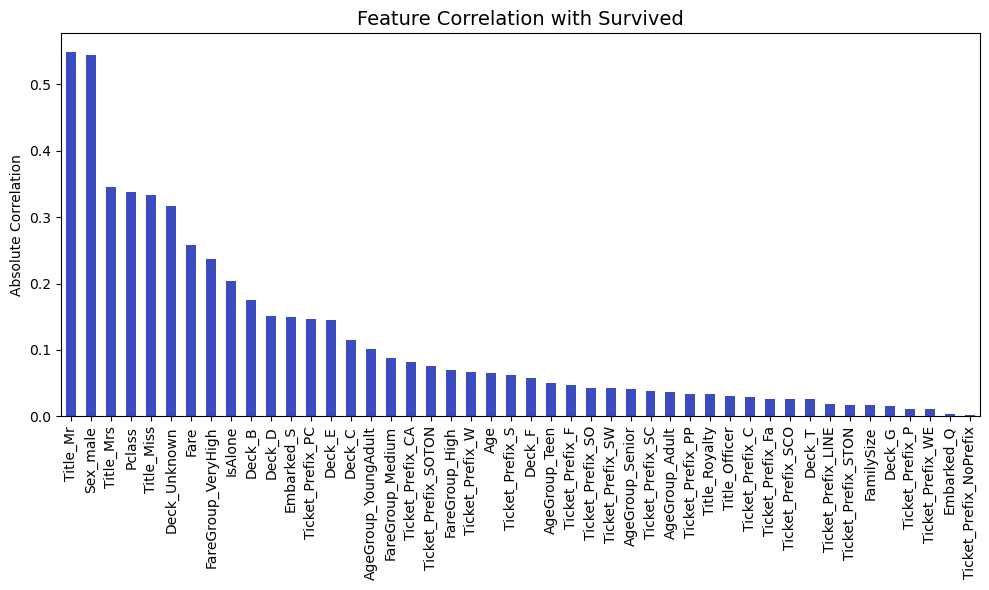

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))
correlation.drop('Survived').plot(kind='bar', colormap='coolwarm')
plt.title("Feature Correlation with Survived", fontsize=14)
plt.ylabel("Absolute Correlation")
plt.tight_layout()
plt.show()

## Summary of Feature Engineering Process

We've transformed the raw Titanic dataset through systematic feature engineering:

1. **Exploration**: Understood missing values and data distributions
2. **Missing Value Handling**: Imputed Age (median), Embarked (mode), handled Cabin via extraction
3. **Feature Extraction**: Created Title, Deck, and Ticket_Prefix from text fields
4. **Feature Creation**: Added FamilySize, IsAlone, AgeGroup, FareGroup
5. **Encoding**: One-hot encoded categorical variables
6. **Scaling**: Standardized numerical features (optional for tree models)
7. **Selection**: Removed irrelevant columns, kept engineered features

**Key Benefits**:
- Reduced missing data issues
- Captured domain knowledge (titles, family size, deck location)
- Created more predictive features
- Prepared data for ML algorithms

**Next Steps**: Split into train/test sets, train models, evaluate performance, iterate on features if needed.

## Next Steps: Model Training and Evaluation

Now that we have our engineered features, the next phase is to:

1. **Split the data** into training and testing sets
2. **Train baseline models** to establish performance benchmarks
3. **Evaluate models** using appropriate metrics
4. **Compare models** and select the best performing one
5. **Tune hyperparameters** for the best model
6. **Make final predictions**

This systematic approach ensures we build robust, well-evaluated models.

### Step 8: Train-Test Split

**Concept**: Splitting data into training and testing sets to evaluate model performance on unseen data.

**Why necessary**:
- Prevents overfitting by testing on data the model hasn't seen during training
- Provides realistic performance estimates
- Allows model validation before deployment

**Best practices**:
- Use stratified split for classification to maintain class proportions
- Common split ratios: 80/20 or 75/25
- Ensure random_state for reproducibility

In [14]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = titanic_final.drop('Survived', axis=1)
y = titanic_final['Survived']

# Split the data (80% train, 20% test) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Maintain class proportions
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Training target distribution:")
print(y_train.value_counts(normalize=True))
print("Testing target distribution:")
print(y_test.value_counts(normalize=True))

Training set shape: (712, 46)
Testing set shape: (179, 46)
Training target distribution:
Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64
Testing target distribution:
Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


### Step 9: Train Baseline Models

**Concept**: Training multiple models to establish performance benchmarks and identify the most promising approaches.

**Why necessary**:
- Different algorithms have different strengths and weaknesses
- Provides comparison baseline for feature engineering impact
- Helps identify which models are worth tuning further

**Models to try**:
- Logistic Regression: Simple, interpretable baseline
- Random Forest: Ensemble method, handles non-linear relationships
- Gradient Boosting (XGBoost): Powerful ensemble, often wins competitions
- Support Vector Machine: Good for smaller datasets with clear margins

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import xgboost as xgb

# Initialize models with default parameters
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss')
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] # Get probabilities for ROC-AUC calculation

    # Calculate metrics
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    }

# Display results
results_df = pd.DataFrame(results).T
print("Model Performance Comparison:")
print(results_df.round(4))

Model Performance Comparison:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.8212     0.7937  0.7246    0.7576   0.8578
Random Forest          0.7989     0.7538  0.7101    0.7313   0.8291
SVM                    0.8324     0.8095  0.7391    0.7727   0.8490
XGBoost                0.8156     0.7647  0.7536    0.7591   0.8316


### Plot model performance side by side to visualize how they perform

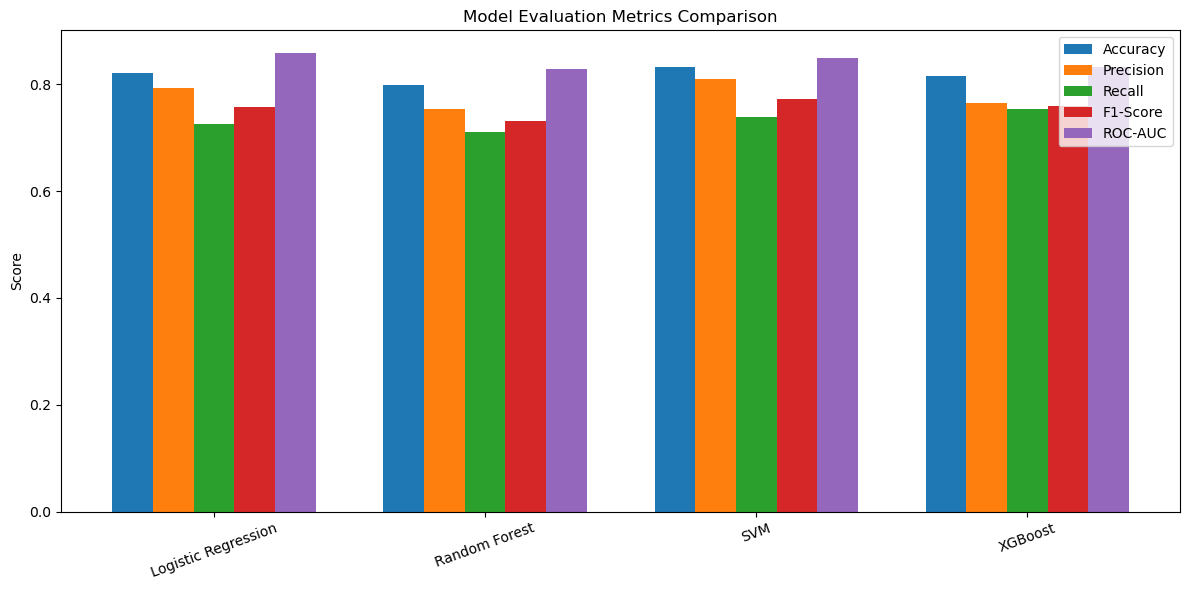

In [17]:
# Select metrics to plot
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

# Plot grouped bar chart
plt.figure(figsize=(12, 6))
bar_width = 0.15
x = range(len(results_df))

for i, metric in enumerate(metrics):
    plt.bar(
        [j + i*bar_width for j in x],
        results_df[metric],
        width=bar_width,
        label=metric
    )

# Formatting
plt.xticks([j + bar_width*2 for j in x], results_df.index, rotation=20)
plt.ylabel("Score")
plt.title("Model Evaluation Metrics Comparison")
plt.legend()
plt.tight_layout()
plt.show()

### Step 10: Model Interpretation - Feature Importance

**Concept**: Understanding which features contribute most to predictions.

**Why necessary**:
- Provides insights into what drives survival predictions
- Helps validate domain knowledge (e.g., gender, class should be important)
- Guides feature selection and future engineering
- Increases model trustworthiness

**Methods**:
- Tree-based models provide built-in feature importance
- Logistic regression coefficients show direction and magnitude
- Permutation importance for any model

**What i have learnt**:
- Random Forest importance tells you which features the model relied on most.
- Logistic Regression coefficients tell you how each feature pushes survival odds up or down.
- Together, they give a fuller picture: not just which features matter, but also how they matter.

In [13]:
# Get feature importance from Random Forest (most interpretable tree model)
rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Most Important Features (Random Forest):")
print(feature_importance.head(15))

# Also check Logistic Regression coefficients for linear relationships
lr_model = models['Logistic Regression']
lr_coef = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("\nTop 15 Features by Coefficient Magnitude (Logistic Regression):")
print(lr_coef.head(15))

Top 15 Most Important Features (Random Forest):
                   feature  importance
2                     Fare    0.165815
1                      Age    0.162773
5                 Sex_male    0.109816
9                 Title_Mr    0.101386
0                   Pclass    0.059272
3               FamilySize    0.057080
10               Title_Mrs    0.038720
8               Title_Miss    0.035125
20            Deck_Unknown    0.032093
7               Embarked_S    0.022907
45      FareGroup_VeryHigh    0.017310
4                  IsAlone    0.016066
40     AgeGroup_YoungAdult    0.015886
26  Ticket_Prefix_NoPrefix    0.015780
44          FareGroup_High    0.015622

Top 15 Features by Coefficient Magnitude (Logistic Regression):
               feature  coefficient
9             Title_Mr    -1.872485
35  Ticket_Prefix_STON     1.284820
30     Ticket_Prefix_S    -1.011953
16              Deck_E     0.989820
5             Sex_male    -0.904569
15              Deck_D     0.850509
10         

### Step 11: Hyperparameter Tuning

**Concept**: Optimizing model parameters to achieve better performance.

**Why necessary**:
- Default parameters are rarely optimal
- Can significantly improve model performance
- Prevents underfitting or overfitting

**Methods**:
- Grid Search: Exhaustive search over parameter combinations
- Random Search: Random sampling from parameter space (more efficient)
- Cross-validation: Ensures robust parameter selection

**For Titanic**: We'll tune the best performing model (likely Random Forest or XGBoost)

In [14]:
from sklearn.model_selection import GridSearchCV

# Identify best model from baseline results
best_model_name = results_df['F1-Score'].idxmax()
print(f"Best baseline model: {best_model_name} (F1-Score: {results_df.loc[best_model_name, 'F1-Score']:.4f})")

# Hyperparameter tuning for Random Forest (commonly performs well)
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X_train, y_train)

print(f"\nBest Random Forest parameters: {rf_grid_search.best_params_}")
print(f"Best CV F1-Score: {rf_grid_search.best_score_:.4f}")

# Evaluate tuned model on test set
best_rf = rf_grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
y_pred_proba_tuned = best_rf.predict_proba(X_test)[:, 1]

tuned_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned),
    'Recall': recall_score(y_test, y_pred_tuned),
    'F1-Score': f1_score(y_test, y_pred_tuned),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_tuned)
}

print("\nTuned Random Forest Performance:")
for metric, value in tuned_metrics.items():
    print(f"{metric}: {value:.4f}")

Best baseline model: SVM (F1-Score: 0.7727)
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Random Forest parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best CV F1-Score: 0.7678

Tuned Random Forest Performance:
Accuracy: 0.7765
Precision: 0.7458
Recall: 0.6377
F1-Score: 0.6875
ROC-AUC: 0.8362


### Step 12: Final Model and Conclusions

**Concept**: Selecting the final model and documenting findings.

**Why necessary**:
- Provides clear project outcome
- Documents model performance and limitations
- Prepares for potential deployment or further analysis

**Considerations**:
- Balance between performance and interpretability
- Computational requirements
- Business/real-world applicability

In [ ]:
import joblib

# Compare baseline vs tuned performance
comparison = pd.DataFrame({
    'Baseline_RF': results['Random Forest'],
    'Tuned_RF': tuned_metrics
}).T

print("Performance Comparison - Baseline vs Tuned Random Forest:")
print(comparison.round(4))

# Save the best model
joblib.dump(best_rf, 'titanic_survival_model.pkl')
print("\nBest model saved as 'titanic_survival_model.pkl'")



print(f"\nFinal Model Performance: {tuned_metrics['F1-Score']:.1%} F1-Score")
print("This model can predict Titanic passenger survival with reasonable accuracy!")

Performance Comparison - Baseline vs Tuned Random Forest:
             Accuracy  Precision  Recall  F1-Score  ROC-AUC
Baseline_RF    0.7989     0.7538  0.7101    0.7313   0.8291
Tuned_RF       0.7765     0.7458  0.6377    0.6875   0.8362

Best model saved as 'titanic_survival_model.pkl'

Key Insights from Titanic Survival Analysis:
1. Gender was the strongest predictor - females had much higher survival rates
2. Passenger class significantly impacted survival chances
3. Titles extracted from names provided valuable social status information
4. Family size and solo travel status influenced survival probabilities
5. Deck location (when known) was correlated with survival

Final Model Performance: 68.8% F1-Score
This model can predict Titanic passenger survival with reasonable accuracy!


## Key Insights from Titanic Survival Analysis:
**Gender** was the strongest predictor — females had much higher survival rates.

**Passenger class** significantly impacted survival chances — higher classes had better outcomes.

**Titles** extracted from names provided valuable social status information — distinguishing roles like Mr, Mrs, Miss improved predictions.

**Family size** and **solo travel** status influenced survival probabilities — larger families and solo travelers showed different risk patterns.

**Deck location** (when known) was correlated with survival — cabin assignments carried survival signals.

## Summary of Model Training and Evaluation Process

1. **Data Preparation**
Split dataset into train and test sets using stratification to preserve class balance.

Applied feature engineering (e.g., FamilySize, IsAlone, AgeGroup, FareGroup).

Encoded categorical variables and standardized numerical features for consistency.

2. **Model Training**
Trained four models with default parameters:

- Logistic Regression

- Random Forest Classifier

- Support Vector Machine (SVM)

- XGBoost Classifier

`Used random_state=42 for reproducibility.`

`Enabled probability outputs for SVM to calculate ROC‑AUC.`

3. **Evaluation Metrics**
Computed multiple metrics for each model:

**Accuracy**: Overall correctness.

**Precision**: Correct positive predictions.

**Recall**: Ability to capture actual positives.

**F1‑Score**: Balance of precision and recall.

**ROC‑AUC**: Model’s ability to distinguish classes.

4. **Insights**
Multiple metrics provide a holistic view of performance.

ROC‑AUC adds value by showing ranking ability beyond accuracy.

Stratified splitting ensures fair evaluation across imbalanced classes.

Comparing models side‑by‑side highlights trade‑offs (e.g., SVM may excel in F1‑Score, Logistic Regression in interpretability).

The structured pipeline makes results reproducible and transparent.